# Ex. TDEM Workflow: From Hydrological Models to EM Responses and Inversion

This notebook demonstrates the TDEM workflow workflow in PyHydroGeophysX.


In [1]:
"""
Ex. TDEM Workflow: From Hydrological Models to EM Responses and Inversion
==========================================================================

This example demonstrates the complete workflow for integrating hydrological 
model outputs (MODFLOW water content) with Time-Domain Electromagnetic (TDEM) 
forward modeling and inversion using SimPEG and PyHydroGeophysX.

The workflow includes:
1. Loading MODFLOW water content and porosity data
2. Extracting 1D profiles from 3D hydrological model
3. Converting water content to electrical conductivity using petrophysical models
4. Forward modeling TDEM responses using PyHydroGeophysX
5. Performing TDEM inversion to recover conductivity structure
6. Comparing recovered vs true models

"""

'\nEx. TDEM Workflow: From Hydrological Models to EM Responses and Inversion\n==========================================================================\n\nThis example demonstrates the complete workflow for integrating hydrological \nmodel outputs (MODFLOW water content) with Time-Domain Electromagnetic (TDEM) \nforward modeling and inversion using SimPEG and PyHydroGeophysX.\n\nThe workflow includes:\n1. Loading MODFLOW water content and porosity data\n2. Extracting 1D profiles from 3D hydrological model\n3. Converting water content to electrical conductivity using petrophysical models\n4. Forward modeling TDEM responses using PyHydroGeophysX\n5. Performing TDEM inversion to recover conductivity structure\n6. Comparing recovered vs true models\n\n'

## Step 1: Import Required Modules

In [2]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from simpeg.utils import plot_1d_layer_model

# Setup package path for development
try:
    current_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    current_dir = os.getcwd()

parent_dir = os.path.dirname(current_dir)
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

# Import PyHydroGeophysX modules
from PyHydroGeophysX.petrophysics.resistivity_models import WS_Model
from PyHydroGeophysX.forward.tdem_forward import TDEMForwardModeling, TDEMSurveyConfig, hydro_to_tdem
from PyHydroGeophysX.inversion.tdem_inversion import TDEMInversion, run_tdem_inversion

# Plotting settings
plt.rcParams.update({"font.size": 14, "lines.linewidth": 2, "lines.markersize": 8})

C:\Users\hchen117\OneDrive - University of Iowa\Documents\GitHub\PyHydroGeophysX\PyHydroGeophysX\__init__.py:15: FutureWarning: Importing `SimPEG` is deprecated. please import from `simpeg`.
  import SimPEG as _simpeg


API path =  C:\Users\hchen117\.conda\envs\pg\lib\site-packages\resipy
ResIPy version =  3.5.4
cR2.exe found and up to date.
R3t.exe found and up to date.
cR3t.exe found and up to date.
[PyHydroGeophysX] RESIPY loaded successfully
[PyHydroGeophysX] PyGIMLi loaded successfully
[PyHydroGeophysX] SimPEG loaded successfully (version 0.24.0)


C:\Users\hchen117\.conda\envs\pg\lib\site-packages\resipy\meshTools.py:56: UserWarning: pyvista not installed, 3D meshing viewing options will be limited
  warnings.warn('pyvista not installed, 3D meshing viewing options will be limited')


## Create output directory


In [3]:
# Create output directory
output_dir = "results/tdem_workflow"
os.makedirs(output_dir, exist_ok=True)

## Step 2: Load MODFLOW Water Content Data

Load the hydrological model outputs (water content and porosity) from MODFLOW simulation.
We'll extract a 1D vertical profile for TDEM sounding simulation.

In [4]:
# Load domain and hydrological data
data_dir = "data/"

# Load domain information
idomain = np.loadtxt(os.path.join(data_dir, "id.txt"))
top = np.loadtxt(os.path.join(data_dir, "top.txt"))
bot = np.load(os.path.join(data_dir, "bot.npy"))

# Load porosity and water content from MODFLOW
porosity_3d = np.load(os.path.join(data_dir, "Porosity.npy"))
water_content_3d = np.load(os.path.join(data_dir, "Watercontent.npy"))

# Use time step 5 (same as ERT workflow example)
water_content = water_content_3d[5]

print(f"Porosity shape: {porosity_3d.shape}")
print(f"Water content shape: {water_content.shape}")
print(f"Number of layers: {len(bot) + 1}")

Porosity shape: (14, 194, 157)
Water content shape: (14, 194, 157)
Number of layers: 15


## Step 3: Extract 1D Vertical Profile

Extract a vertical profile at a specific location for TDEM sounding. 
We'll use a location within the active domain.

In [5]:
# Select a location for 1D TDEM sounding (column, row in the model grid)
col_idx, row_idx = 105, 120  # Example location within active domain

# Extract vertical profile of porosity and water content
porosity_profile = porosity_3d[:, row_idx, col_idx]
wc_profile = water_content[:, row_idx, col_idx]

# Calculate layer thicknesses from top and bottom elevations
layer_tops = np.zeros(len(bot) + 1)
layer_tops[0] = top[row_idx, col_idx]
for i, b in enumerate(bot):
    layer_tops[i + 1] = b[row_idx, col_idx]

# Layer thicknesses: For N layers, we need N-1 thicknesses (last layer extends to infinity)
# np.diff gives N-1 values from N values, but we have N+1 layer_tops for N layers
# So we need to take only the first N-1 thicknesses
all_thicknesses = np.abs(np.diff(layer_tops))
layer_thicknesses = all_thicknesses[:-1]  # N-1 thicknesses for N layers

# Calculate saturation
saturation_profile = wc_profile / porosity_profile

n_layers = len(porosity_profile)
print(f"Number of layers: {n_layers}")
print(f"Number of thicknesses (should be {n_layers-1}): {len(layer_thicknesses)}")
print(f"Layer thicknesses (m): {layer_thicknesses[:5]}... (first 5)")
print(f"Porosity range: {porosity_profile.min():.3f} - {porosity_profile.max():.3f}")
print(f"Saturation range: {saturation_profile.min():.3f} - {saturation_profile.max():.3f}")

Number of layers: 14
Number of thicknesses (should be 13): 13
Layer thicknesses (m): [0.59381752 0.59381752 0.59381752 0.59381752 4.        ]... (first 5)
Porosity range: 0.050 - 0.450
Saturation range: 0.130 - 1.000


## Step 4: Convert to Electrical Conductivity

Use the Waxman-Smits petrophysical model to convert hydrological properties 
(water content, porosity) to electrical conductivity.

In [6]:
# Define petrophysical parameters
# These can vary by layer based on geology

n_layers = len(porosity_profile)

# Pore water conductivity (S/m) - typical groundwater
sigma_w = np.full(n_layers, 0.05)  # ~20 Ohm-m water

# Cementation exponent - varies with rock type
# Higher values for tighter rock
m = np.ones(n_layers) * 1.5
m[4:] = 1.8  # Fractured bedrock below layer 4

# Saturation exponent
n = np.ones(n_layers) * 2.0

# Surface conductivity (clay contribution) - mainly in shallow layers
sigma_s = np.zeros(n_layers)
sigma_s[:4] = 0.01  # Surface conductivity in regolith

# Calculate resistivity using Waxman-Smits model
resistivity = np.zeros(n_layers)
for i in range(n_layers):
    resistivity[i] = WS_Model(
        saturation_profile[i],
        porosity_profile[i],
        sigma_w[i],
        m[i],
        n[i],
        sigma_s[i]
    )

# Convert to conductivity
conductivity = 1.0 / resistivity

print(f"Conductivity range: {conductivity.min():.4f} - {conductivity.max():.4f} S/m")
print(f"Resistivity range: {resistivity.min():.1f} - {resistivity.max():.1f} Ohm-m")

Conductivity range: 0.0002 - 0.0032 S/m
Resistivity range: 313.8 - 4394.2 Ohm-m


## Visualize the true 1D conductivity model


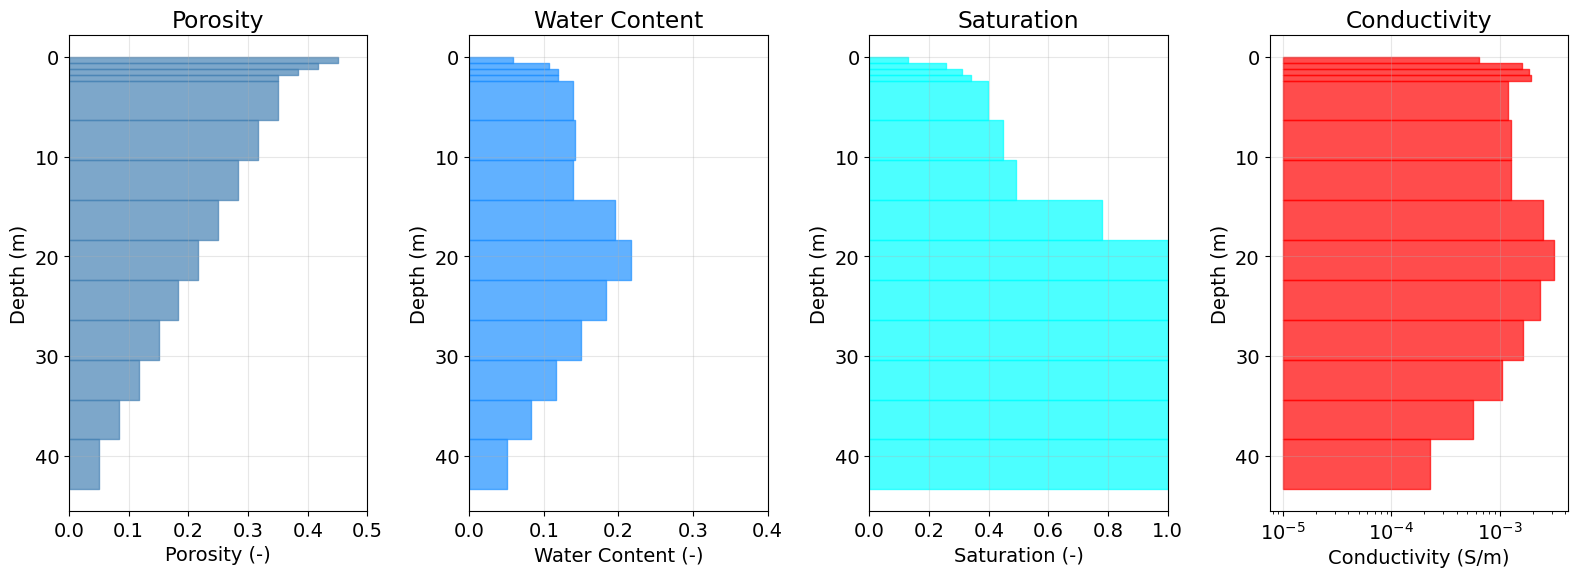

In [7]:
# Visualize the true 1D conductivity model
fig, axes = plt.subplots(1, 4, figsize=(16, 6))

# Cumulative depth for plotting - add extra depth for last layer (extends to infinity)
# Use a reasonable plotting depth for the last layer
last_layer_thickness = 5.0  # Arbitrary thickness for plotting the last layer
depths = np.cumsum(np.r_[0, layer_thicknesses, last_layer_thickness])

# Number of layers to plot (all n_layers)
n_plot = n_layers

# Porosity profile
ax1 = axes[0]
for i in range(n_plot):
    ax1.fill_betweenx([depths[i], depths[i+1]], 0, porosity_profile[i], alpha=0.7, color='steelblue')
ax1.set_xlabel('Porosity (-)')
ax1.set_ylabel('Depth (m)')
ax1.set_title('Porosity')
ax1.set_xlim(0, 0.5)
ax1.invert_yaxis()
ax1.grid(True, alpha=0.3)

# Water content profile
ax2 = axes[1]
for i in range(n_plot):
    ax2.fill_betweenx([depths[i], depths[i+1]], 0, wc_profile[i], alpha=0.7, color='dodgerblue')
ax2.set_xlabel('Water Content (-)')
ax2.set_ylabel('Depth (m)')
ax2.set_title('Water Content')
ax2.set_xlim(0, 0.4)
ax2.invert_yaxis()
ax2.grid(True, alpha=0.3)

# Saturation profile
ax3 = axes[2]
for i in range(n_plot):
    ax3.fill_betweenx([depths[i], depths[i+1]], 0, saturation_profile[i], alpha=0.7, color='cyan')
ax3.set_xlabel('Saturation (-)')
ax3.set_ylabel('Depth (m)')
ax3.set_title('Saturation')
ax3.set_xlim(0, 1.0)
ax3.invert_yaxis()
ax3.grid(True, alpha=0.3)

# Conductivity profile
ax4 = axes[3]
for i in range(n_plot):
    ax4.fill_betweenx([depths[i], depths[i+1]], 1e-5, conductivity[i], alpha=0.7, color='red')
ax4.set_xlabel('Conductivity (S/m)')
ax4.set_ylabel('Depth (m)')
ax4.set_title('Conductivity')
ax4.set_xscale('log')
ax4.invert_yaxis()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "true_model_profiles.png"), dpi=150)
plt.show()

## Step 5: TDEM Forward Modeling

Use PyHydroGeophysX's TDEMForwardModeling class to compute the TDEM response 
for a circular loop source with step-off waveform.

In [8]:
# Define TDEM survey configuration
times = np.logspace(-5, -2, 31)  # 10 µs to 10 ms

survey_config = TDEMSurveyConfig(
    source_location=np.array([0.0, 0.0, 0.0]),
    source_radius=10.0,  # 10 m loop radius
    source_current=1.0,
    receiver_location=np.array([0.0, 0.0, 0.0]),
    receiver_orientation="z",
    times=times,
    waveform_type="step_off"
)

print(f"TDEM Survey Configuration:")
print(f"  Loop radius: {survey_config.source_radius} m")
print(f"  Time channels: {len(times)} points ({times[0]*1e6:.1f} µs to {times[-1]*1e3:.1f} ms)")

TDEM Survey Configuration:
  Loop radius: 10.0 m
  Time channels: 31 points (10.0 µs to 10.0 ms)


## Create forward modeler


In [9]:
# Create forward modeler
fwd = TDEMForwardModeling(
    thicknesses=layer_thicknesses,
    survey_config=survey_config
)

# Compute forward response with noise
noise_level = 0.05  # 5% noise
dobs, dpred_clean, uncertainties = fwd.forward_with_noise(
    conductivity,
    noise_level=noise_level,
    seed=42
)

print(f"Forward modeling complete!")
print(f"  Number of data points: {len(dobs)}")
print(f"  Data range: {np.abs(dobs).min():.2e} to {np.abs(dobs).max():.2e} T")

Forward modeling complete!
  Number of data points: 31
  Data range: 6.83e-18 to 2.98e-12 T


## Step 6: Plot Synthetic TDEM Data

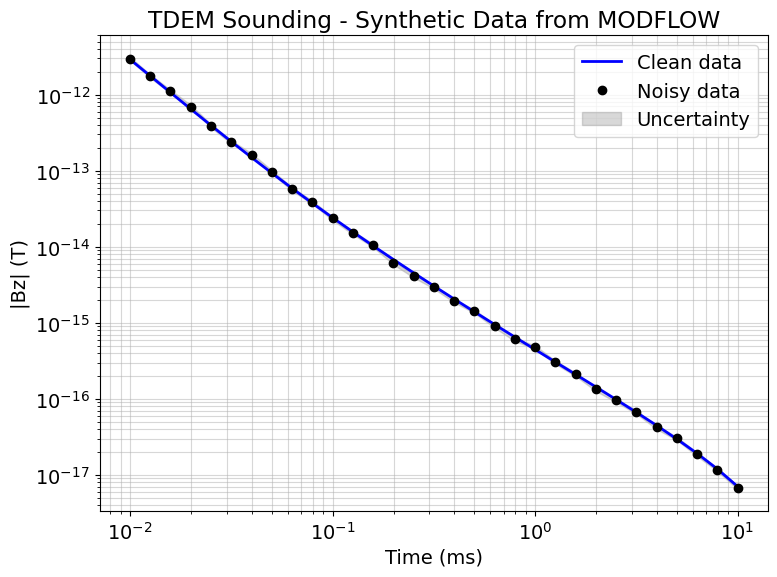

In [10]:
# Plot observed data
fig, ax = plt.subplots(figsize=(8, 6))

ax.loglog(times * 1e3, np.abs(dpred_clean), 'b-', lw=2, label='Clean data')
ax.loglog(times * 1e3, np.abs(dobs), 'ko', markersize=6, label='Noisy data')
ax.fill_between(times * 1e3, 
                np.abs(dobs) - uncertainties, 
                np.abs(dobs) + uncertainties, 
                alpha=0.3, color='gray', label='Uncertainty')

ax.set_xlabel('Time (ms)')
ax.set_ylabel('|Bz| (T)')
ax.set_title('TDEM Sounding - Synthetic Data from MODFLOW')
ax.legend()
ax.grid(True, which='both', alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "synthetic_tdem_data.png"), dpi=150)
plt.show()

## Step 7: Save Synthetic Data

In [11]:
# Save data to file
data_file = os.path.join(output_dir, "tdem_synthetic_data.txt")
np.savetxt(data_file, np.c_[times, dobs, uncertainties], 
           fmt="%.6e", header="TIME(s) BZ(T) UNCERTAINTY(T)")

print(f"Data saved to: {data_file}")

Data saved to: results/tdem_workflow\tdem_synthetic_data.txt


## Step 8: Run TDEM Inversion

Use PyHydroGeophysX's TDEMInversion class to recover the conductivity structure from the synthetic data.

In [12]:
# Calculate max depth of true model to set appropriate inversion depth
true_max_depth = np.sum(layer_thicknesses)
print(f"True model max depth: {true_max_depth:.1f} m")

# Create TDEM inversion object with depth matching true model
tdem_inv = TDEMInversion(
    times=times,
    dobs=dobs,
    uncertainties=uncertainties,
    source_radius=10.0,
    n_layers=20,  # Number of layers for inversion mesh
    min_thickness=0.5,  # Thinner layers for better resolution
    max_thickness=5.0,  # Max thickness to keep total depth reasonable
    starting_conductivity=0.001,  # Closer to expected range
    use_irls=True,  # Use sparse regularization
    max_iterations=50,
    verbose=True
)

print("TDEM Inversion configured!")

True model max depth: 38.4 m
TDEM Inversion configured!


## Run the inversion


In [13]:
# Run the inversion
result = tdem_inv.run()

print(f"\nInversion Results:")
print(f"  Final chi-squared: {result.chi2:.3f}")
print(f"  Recovered conductivity range: {result.recovered_conductivity.min():.4f} - {result.recovered_conductivity.max():.4f} S/m")

Inversion setup complete:
  - 20 layers
  - Thickness range: 0.50 - 5.00 m
  - 31 data points
Starting model: 0.0010 S/m

Running TDEM inversion...

Running inversion with SimPEG v0.24.0

                    simpeg.InvProblem is setting bfgsH0 to the inverse of the eval2Deriv.
                    ***Done using the default solver Pardiso and no solver_opts.***
                    


model has any nan: 0
=============================== Projected GNCG ===============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
x0 has any nan: 0
   0  5.56e+08  4.67e+05  0.00e+00  4.67e+05    1.55e+06      0              
   1  2.78e+08  4.26e+05  3.63e-05  4.36e+05    6.84e+05      0              


   2  1.39e+08  3.95e+05  1.24e-04  4.12e+05    6.41e+05      0   Skip BFGS  
   3  6.96e+07  3.44e+05  4.04e-04  3.72e+05    5.51e+05      0   Skip BFGS  


   4  3.48e+07  2.77e+05  1.15e-03  3.18e+05    4.38e+05      0   Skip BFGS  
   5  1.74e+07  2.05e+05  2.81e-03  2.54e+05    3.21e+05      0   Skip BFGS  


   6  8.69e+06  1.39e+05  5.87e-03  1.90e+05    2.20e+05      0   Skip BFGS  
   7  4.35e+06  8.80e+04  1.07e-02  1.35e+05    1.44e+05      0   Skip BFGS  


...

  11  2.72e+05  8.48e+03  4.72e-02  2.13e+04    1.96e+04      0   Skip BFGS  
  12  1.36e+05  4.56e+03  5.87e-02  1.25e+04    1.15e+04      0   Skip BFGS  


  13  6.79e+04  2.40e+03  7.09e-02  7.22e+03    6.83e+03      0   Skip BFGS  
  14  3.40e+04  9.16e+02  8.59e-02  3.83e+03    4.83e+03      0   Skip BFGS  


  15  1.70e+04  2.91e+02  9.85e-02  1.96e+03    2.29e+03      0   Skip BFGS  
  16  8.49e+03  1.05e+02  1.06e-01  1.01e+03    1.19e+03      0   Skip BFGS  


  17  4.25e+03  4.55e+01  1.11e-01  5.17e+02    6.17e+02      0   Skip BFGS  
Reached starting chifact with l2-norm regularization: Start IRLS steps...
irls_threshold 1.4739570692646335
  18  4.25e+03  2.80e+01  1.12e-01  5.04e+02    1.50e+01      0   Skip BFGS  


  19  5.17e+03  2.77e+01  1.12e-01  6.07e+02    7.83e+01      1              
Minimum decrease in regularization. End of IRLS
------------------------- STOP! -------------------------
1 : |fc-fOld| = 0.0000e+00 <= tolF*(1+|f0|) = 4.6696e+04
1 : |xc-x_last| = 5.0762e-01 <= tolX*(1+|x0|) = 3.2655e+00
0 : |proj(x-g)-x|    = 7.8298e+01 <= tolG          = 1.0000e-01
0 : |proj(x-g)-x|    = 7.8298e+01 <= 1e3*eps       = 1.0000e-02
0 : maxIter   =      50    <= iter          =     20
------------------------- DONE! -------------------------
Inversion complete!

Final chi-squared: 0.991

Inversion Results:
  Final chi-squared: 0.991
  Recovered conductivity range: 0.0002 - 0.0032 S/m


## Step 9: Plot Results - Compare True and Recovered Models

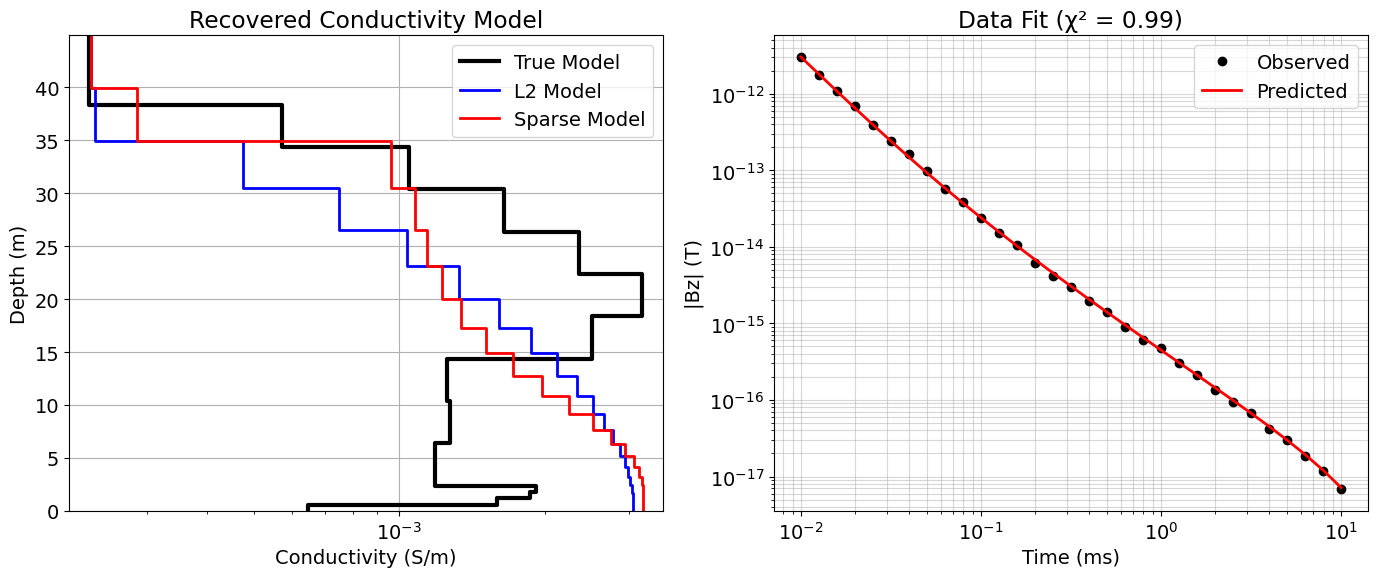

In [14]:
# Use the built-in plotting method
tdem_inv.plot_result(
    result,
    true_model=(layer_thicknesses, conductivity),
    save_path=os.path.join(output_dir, "inversion_result.png")
)

## Step 10: Detailed Model Comparison

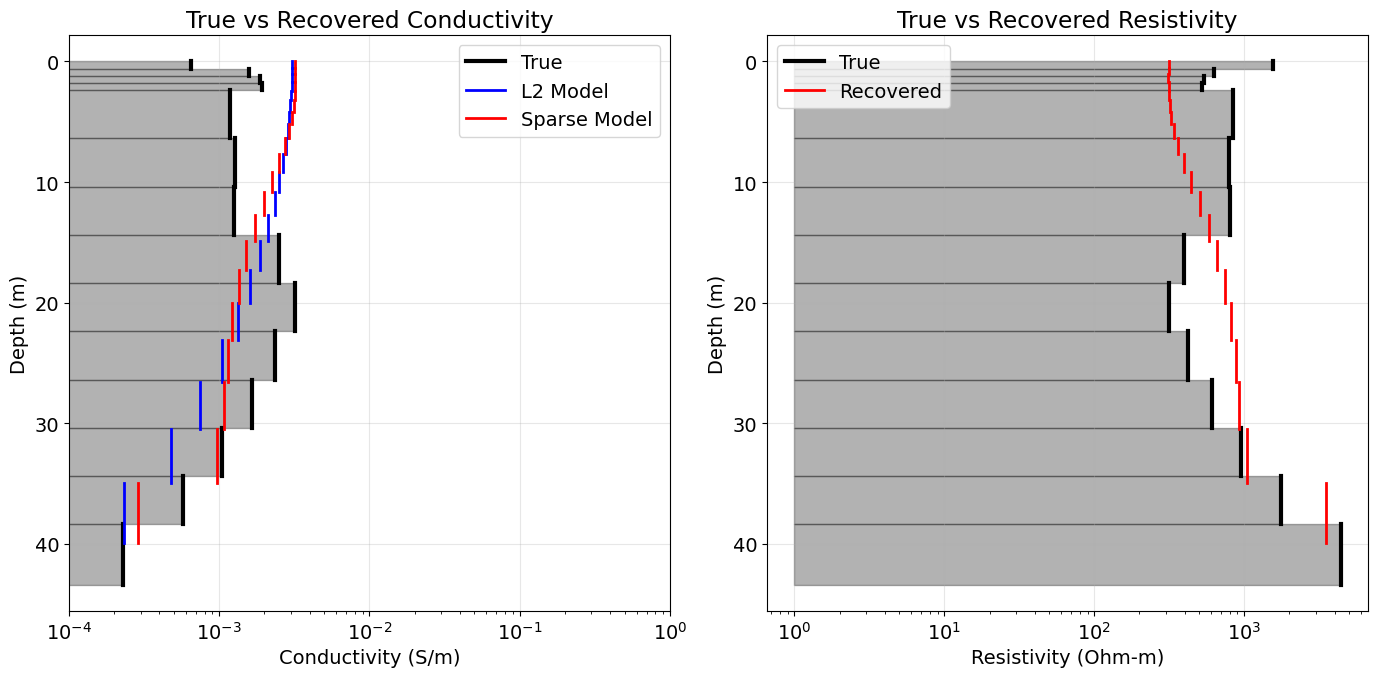

In [15]:
# Detailed comparison plot
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Model comparison (conductivity)
ax1 = axes[0]

# True model - step plot
for i in range(n_layers):
    ax1.fill_betweenx([depths[i], depths[i+1]], 1e-5, conductivity[i], 
                      alpha=0.3, color='black')
    ax1.plot([conductivity[i], conductivity[i]], [depths[i], depths[i+1]], 
             'k-', lw=3, label='True' if i == 0 else '')

# L2 model
if result.l2_conductivity is not None:
    inv_depths = np.cumsum(np.r_[0, result.thicknesses])
    for i in range(len(result.l2_conductivity)):
        if i < len(inv_depths) - 1:
            ax1.plot([result.l2_conductivity[i], result.l2_conductivity[i]], 
                     [inv_depths[i], inv_depths[i+1]], 'b-', lw=2, 
                     label='L2 Model' if i == 0 else '')

# Sparse model
for i in range(len(result.recovered_conductivity)):
    if i < len(inv_depths) - 1:
        ax1.plot([result.recovered_conductivity[i], result.recovered_conductivity[i]], 
                 [inv_depths[i], inv_depths[i+1]], 'r-', lw=2, 
                 label='Sparse Model' if i == 0 else '')

ax1.set_xscale('log')
ax1.set_xlabel('Conductivity (S/m)')
ax1.set_ylabel('Depth (m)')
ax1.set_title('True vs Recovered Conductivity')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.invert_yaxis()
ax1.set_xlim(1e-4, 1)

# Resistivity comparison
ax2 = axes[1]

# True model
for i in range(n_layers):
    ax2.fill_betweenx([depths[i], depths[i+1]], 1, resistivity[i], 
                      alpha=0.3, color='black')
    ax2.plot([resistivity[i], resistivity[i]], [depths[i], depths[i+1]], 
             'k-', lw=3, label='True' if i == 0 else '')

# Sparse model (resistivity)
rec_resistivity = 1.0 / result.recovered_conductivity
for i in range(len(rec_resistivity)):
    if i < len(inv_depths) - 1:
        ax2.plot([rec_resistivity[i], rec_resistivity[i]], 
                 [inv_depths[i], inv_depths[i+1]], 'r-', lw=2, 
                 label='Recovered' if i == 0 else '')

ax2.set_xscale('log')
ax2.set_xlabel('Resistivity (Ohm-m)')
ax2.set_ylabel('Depth (m)')
ax2.set_title('True vs Recovered Resistivity')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "model_comparison_detailed.png"), dpi=150)
plt.show()

## Data fit comparison


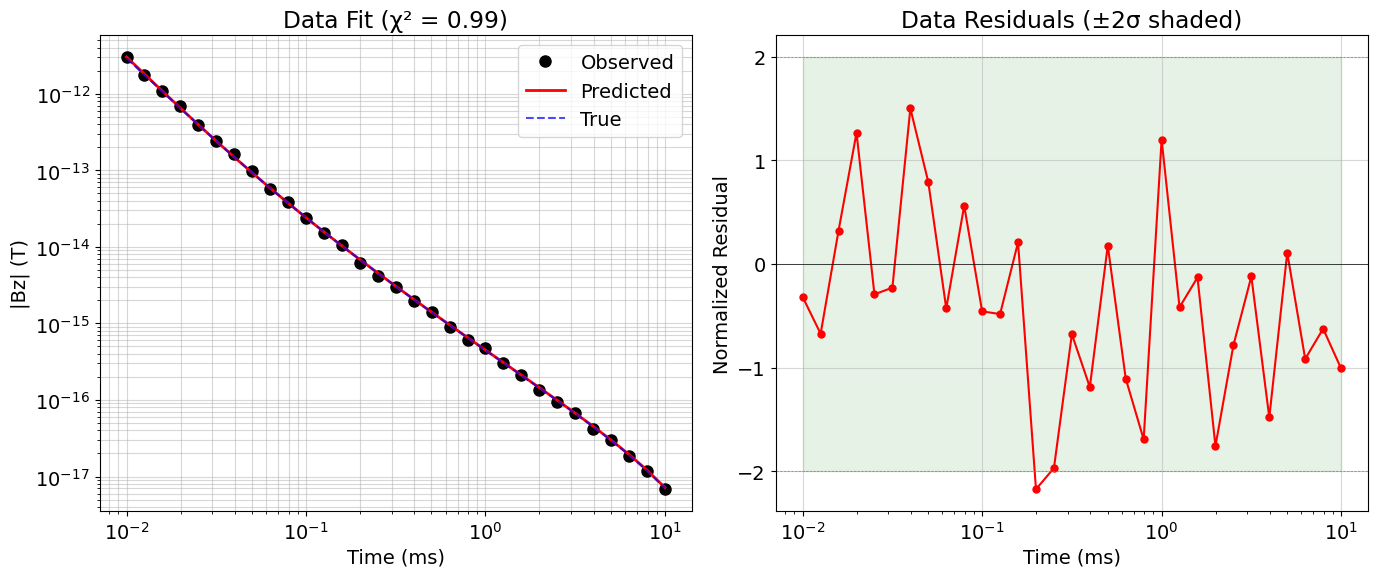

In [16]:
# Data fit comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Data comparison
ax1 = axes[0]
ax1.loglog(times * 1e3, np.abs(dobs), 'ko', markersize=8, label='Observed')
ax1.loglog(times * 1e3, np.abs(result.predicted_data), 'r-', lw=2, label='Predicted')
ax1.loglog(times * 1e3, np.abs(dpred_clean), 'b--', lw=1.5, alpha=0.7, label='True')

ax1.set_xlabel('Time (ms)')
ax1.set_ylabel('|Bz| (T)')
ax1.set_title(f'Data Fit (χ² = {result.chi2:.2f})')
ax1.legend()
ax1.grid(True, which='both', alpha=0.5)

# Residuals
ax2 = axes[1]
residual = (dobs - result.predicted_data) / uncertainties

ax2.semilogx(times * 1e3, residual, 'ro-', lw=1.5, markersize=5)
ax2.axhline(0, color='k', linestyle='-', lw=0.5)
ax2.axhline(2, color='gray', linestyle='--', lw=0.5)
ax2.axhline(-2, color='gray', linestyle='--', lw=0.5)
ax2.fill_between(times * 1e3, -2, 2, alpha=0.1, color='green')

ax2.set_xlabel('Time (ms)')
ax2.set_ylabel('Normalized Residual')
ax2.set_title('Data Residuals (±2σ shaded)')
ax2.grid(True, alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "data_fit.png"), dpi=150)
plt.show()

## Step 11: Inversion Statistics

In [17]:
# Print inversion statistics
print("=" * 50)
print("TDEM INVERSION SUMMARY")
print("=" * 50)
print(f"\nData Statistics:")
print(f"  Number of data points: {len(dobs)}")
print(f"  Time range: {times[0]*1e6:.1f} µs - {times[-1]*1e3:.1f} ms")

print(f"\nModel Statistics:")
print(f"  Number of inversion layers: {len(result.recovered_conductivity)}")
print(f"  True conductivity range: {conductivity.min():.4f} - {conductivity.max():.4f} S/m")
print(f"  Recovered conductivity range: {result.recovered_conductivity.min():.4f} - {result.recovered_conductivity.max():.4f} S/m")

print(f"\nMisfit:")
print(f"  Final chi-squared: {result.chi2:.3f}")
print(f"  Target chi-squared: 1.0")

# Compute RMS error
rms = np.sqrt(np.mean((dobs - result.predicted_data)**2))
print(f"  RMS data error: {rms:.2e} T")
print("=" * 50)

TDEM INVERSION SUMMARY

Data Statistics:
  Number of data points: 31
  Time range: 10.0 µs - 10.0 ms

Model Statistics:
  Number of inversion layers: 21
  True conductivity range: 0.0002 - 0.0032 S/m
  Recovered conductivity range: 0.0002 - 0.0032 S/m

Misfit:
  Final chi-squared: 0.991
  Target chi-squared: 1.0
  RMS data error: 1.63e-14 T


## Step 12: Save Results

In [18]:
# Save inversion results
np.save(os.path.join(output_dir, "recovered_conductivity.npy"), result.recovered_conductivity)
np.save(os.path.join(output_dir, "recovered_model_log.npy"), result.recovered_model)
np.save(os.path.join(output_dir, "true_conductivity.npy"), conductivity)
np.save(os.path.join(output_dir, "true_layer_thicknesses.npy"), layer_thicknesses)
np.save(os.path.join(output_dir, "inv_thicknesses.npy"), result.thicknesses)
np.save(os.path.join(output_dir, "predicted_data.npy"), result.predicted_data)

print(f"Results saved to: {output_dir}")

Results saved to: results/tdem_workflow


## Summary

This workflow demonstrated the complete integration of hydrological and electromagnetic geophysics:

### Workflow Steps:
1. **Load MODFLOW Data**: Extracted water content and porosity from 3D hydrological model
2. **Extract 1D Profile**: Selected a vertical profile for TDEM sounding simulation
3. **Petrophysical Conversion**: Converted hydrological properties to electrical conductivity using Waxman-Smits model
4. **TDEM Forward Modeling**: Used `TDEMForwardModeling` class to compute synthetic electromagnetic responses
5. **TDEM Inversion**: Used `TDEMInversion` class to recover conductivity structure with sparse regularization

### Key PyHydroGeophysX Components Used:
- `TDEMForwardModeling`: 1D layered Earth forward modeling with SimPEG
- `TDEMSurveyConfig`: Configuration for TDEM survey geometry
- `TDEMInversion`: 1D TDEM inversion with L2 and IRLS sparse regularization
- `WS_Model`: Waxman-Smits petrophysical model for resistivity

### Observations:
- The sparse inversion recovers blocky conductivity structures
- TDEM is sensitive to conductive zones in the subsurface
- The recovered model matches the general conductivity trends of the true model
- Chi-squared ≈ 1 indicates good data fit

### Next Steps:
- Apply to multiple time steps for time-lapse TDEM monitoring
- Compare with ERT results for joint interpretation
- Extend to multiple soundings for pseudo-2D imaging